# Livrable 2 — Attention Model pour le VRPTW
**Recherche Opérationnelle** · Phase 4 · Méthode : Attention Model (AM) — Apprentissage par Imitation

---

| | |
|---|---|
| **Algorithme** | Attention Model (Kool et al., 2019) — Transformer + décodeur contraint |
| **Instances** | 30 instances × 5 tailles ($n \in \{10, 20, 50, 100, 200\}$) |
| **Validité** | 100 % de solutions faisables |
| **Langage** | Python 3 · PyTorch · NumPy · pandas · matplotlib |

In [21]:
import os, sys, time, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.lines import Line2D
import matplotlib.patches as mpatches
from scipy import stats as sp_stats

# ═══════════════════════════════════════════════════════════════════════
#  DESIGN SYSTEM — copier ce bloc pour harmoniser les graphiques d'équipe
#  Seul METHODE_CONFIG change d'un binôme à l'autre
# ═══════════════════════════════════════════════════════════════════════

STYLE_CONFIG = {
    'couleur_primaire' : '#2176AE',
    'couleur_alt'      : '#FF6B35',
    'couleur_ic'       : '#A8D5F5',
    'couleur_grid'     : '#E8E8E8',
    'couleur_fond'     : '#FAFAFA',
    'couleur_oracle'   : '#2ECC71',
    'couleur_train'    : '#9B59B6',
    'font_titre'       : {'fontsize': 14, 'fontweight': 'bold', 'color': '#1a1a1a'},
    'font_sous_titre'  : {'fontsize': 11, 'fontstyle': 'italic', 'color': '#555555'},
    'font_axe'         : {'fontsize': 10},
    'font_legende'     : {'size': 9},
    'font_annot'       : {'fontsize': 7.5, 'family': 'monospace', 'color': '#1a1a1a'},
    'figsize_simple'   : (8, 5),
    'figsize_double'   : (12, 5),
    'figsize_quad'     : (13, 10),
    'marker'           : 'o',
    'linestyle'        : '-',
    'linewidth'        : 2.0,
    'markersize'       : 6,
    'dpi'              : 130,
    'grid_alpha'       : 0.5,
    'box_alpha'        : 0.85,
}

METHODE_CONFIG = {
    'nom'          : 'Attention Model (AM)',
    'oracle_path'  : os.path.join('..', 'Benchmark', 'results', 'oracle_results.json'),
    'am_path'      : os.path.join('..', 'Benchmark', 'results', 'am_results.json'),
    'history_path' : os.path.join('artifacts_train_small', 'history.json'),
    'benchmark_path': os.path.join('benchmark_final.json'),
}

FIG_DIR = os.path.join('resultats_livrable')
os.makedirs(FIG_DIR, exist_ok=True)

PHASE4 = os.path.abspath('.')
if PHASE4 not in sys.path:
    sys.path.insert(0, PHASE4)

print(f'Méthode : {METHODE_CONFIG["nom"]}')
print(f'Figures → {FIG_DIR}/')

Méthode : Attention Model (AM)
Figures → resultats_livrable/


---
## 2. Vulgarisation — Le GPS Neuronal

### L'analogie du GPS intelligent

Imaginez que vous deviez livrer des colis avec **plusieurs camions** à travers une ville,
chaque client attendant sa livraison dans un **créneau horaire précis**.
Un GPS classique calcule l'itinéraire optimal à partir de zéro à chaque fois.
Un **GPS neuronal**, lui, a observé des millions de livraisons passées et a appris
quelles décisions mènent aux meilleures tournées — sans recalculer.

### Étape 1 — Mémoriser la carte (Encodeur)

> Le modèle "photographie" toute l'instance : position de chaque client, ses créneaux,
> sa demande, et **ses relations avec les autres clients**.
> C'est le rôle du **Transformer** : chaque client analyse ses voisins simultanément.
> Cette photo est calculée **une seule fois** par instance.

### Étape 2 — Choisir la prochaine destination (Décodeur)

> À chaque carrefour, le modèle pose la question :
> *"Vu où je suis, ce qu'il reste à livrer et l'heure qu'il est — quel client dois-je visiter ?"*
> Il compare son **état courant** (la requête) à chaque **client candidat** (les clés)
> et choisit celui qui correspond le mieux. Les clients dont les créneaux sont fermés
> sont automatiquement bloqués.

### Étape 3 — Apprendre par imitation

> On a montré au modèle des **solutions optimales** produites par un solveur exact (OR-Tools).
> À chaque décision, le modèle a essayé de reproduire le choix du solveur.
> Après 50 époques d'entraînement sur des milliers de décisions, le modèle
> imite correctement le solveur dans **~83 % des cas**.

### Pourquoi c'est révolutionnaire ?

| | Heuristique classique | Attention Model |
|--|--|--|
| **Temps par instance** | $O(n^2)$ à $O(n^3)$ | $O(n)$ (encodeur calculé 1×) |
| **Améliore avec l'expérience** | Non | Oui (entraînement) |
| **Généralise** | Règles fixes | Apprend des patterns |
| **Optimum garanti** | Non | Non (mais bon gap ~8-30%) |

---
## 3. Méthodologie Technique

### 3.1 Architecture générale

Node_features --> Encodeur(Transformer) -h embedings

Action_features, current_node, dynamic_global, feasable_mask --> Décodeur Greedy q Context(Requetes) k key(Clé) Score -> Argmax 


### 3.2 L'Encodeur — Transformer Self-Attention

Le Transformer permet à chaque nœud de "regarder" tous les autres simultanément :

$$\text{Attention}(Q, K, V) = \text{softmax}\left(\frac{QK^\top}{\sqrt{d_k}}\right) V$$

Avec **8 têtes en parallèle** (Multi-Head Attention), chaque tête peut apprendre
un aspect différent : proximité géographique, compatibilité des créneaux, etc.

**3 couches Transformer** avec pré-normalisation (norm_first=True) pour la stabilité.

### 3.3 Le Décodeur — Attention Requête-Clé

À chaque décision, le décodeur construit :

$$q = W_Q \cdot \text{context\_proj}([h_{\text{cur}} \,|\, \bar{h} \,|\, g]) \qquad \in \mathbb{R}^{128}$$

$$k_i = W_K \cdot \text{key\_proj}([h_i \,|\, af_i]) \qquad \in \mathbb{R}^{128}$$

$$\text{score}_i = 10 \cdot \tanh\left(\frac{q \cdot k_i}{\sqrt{128} \cdot 10}\right)$$

Le clipping $10 \cdot \tanh$ (convention Kool et al. 2019) borne les scores dans $[-10, +10]$
et stabilise l'apprentissage en évitant la saturation du softmax.

### 3.4 Stratégie de décodage — Greedy

Le décodeur utilise une politique **greedy** : à chaque étape, le nœud avec le score le plus élevé est sélectionné.

$$a_t = \arg\max_i \text{ score}_i(s_t)$$

Cette stratégie est cohérente avec l'entraînement par **Behavioral Cloning** :
le modèle a appris à scorer les nœuds en supposant que chaque décision précédente
était elle-même greedy.

> **Note — Beam Search évalué et rejeté :** testé à l'inférence (W=20), il **dégrade**
> la solution (+4 à +8 pts de gap pour $n \geq 100$). Cause : *distribution shift* —
> le beam explore des chemins que le modèle n'a jamais évalués pendant l'entraînement.

### 3.5 Hybridation — Cluster-Then-Route pour $n > 50$

Pour les grandes instances, le modèle greedy souffre d'un biais : entraîné sur $n=10$,
il doit enchaîner $100$ ou $200$ décisions, et les erreurs s'accumulent.

L'idée du **Cluster-Then-Route (CTR)** est de ramener chaque sous-problème
dans la distribution d'entraînement :

1. **Cluster** : K-means géographique sur les $n$ clients → $K$ groupes de $\sim n/K$ clients (un par véhicule)
2. **Route** : AM greedy sur chaque sous-instance $(\text{dépôt} + \text{cluster})$ — $\sim 8\text{–}16$ clients, dans la distribution d'entraînement

$$\text{coût\_CTR} = \sum_{k=1}^{K} \text{AM-greedy}(\text{dépôt} + C_k)$$

| $n$ | $K$ | Taille de cluster | Dans la distrib. d'entraînement ? |
|-----|-----|-------------------|-----------------------------------|
| 10  | 3   | 3–4 clients       |  Oui |
| 50  | 6   | 8–9 clients       |  Oui |
| 100 | 12  | 8–9 clients       |  Oui ← CTR activé |
| 200 | 25  | 8 clients         |  Oui ← CTR activé |

Pour $n \leq 50$, le CTR = AM greedy (pas de clustering nécessaire).

### 3.6 Apprentissage par Imitation (Behavioural Cloning)

On minimise la **Cross-Entropy Loss** entre les décisions du modèle et celles de l'oracle :

$$\mathcal{L} = -\sum_{t} \log P_\theta(a_t^* \mid s_t)$$

où $a_t^*$ est le nœud choisi par l'oracle à l'étape $t$ et $s_t$ l'état courant.

**695 936 paramètres** optimisés par Adaptative Moment Estimation sur 50 époques.

### 3.7 Features utilisées

| Tenseur | Shape | Contenu |
|---------|-------|---------|
| `node_features` | $(N+1, 7)$ | $x/100,\, y/100,\, d/Q,\, a/T,\, b/T,\, s/T,\, \mathbb{1}_{\text{dépôt}}$ |
| `action_features` | $(N+1, 5)$ | dist, slack TW, $a/T$, $b/T$, $d/Q$ (dynamiques) |
| `dynamic_global` | $(6,)$ | temps, charge, %servis, %route, véhicules, étape |

### 3.8 Le masque contraint — Garantie de faisabilité

Contrairement aux métaheuristiques qui pénalisent les violations,
l'AM **interdit structurellement** les nœuds infaisables via le masque.

| Condition | Masque mis à 0 |
|-----------|----------------|
| Client déjà servi | ✓ |
| Fenêtre TW fermée (arriverait trop tard) | ✓ |
| Capacité insuffisante | ✓ |
| Dépôt (sauf fin de route) | ✓ |

```
score infaisable → masked_fill(-1e9) → exp(-1e9) ≈ 0 → proba = 0 → jamais choisi
```

**Résultat : 100 % de solutions faisables** sur tous les benchmarks.

---
## 5. Chargement des Données

In [22]:
from preprocess import generate_instance
from inference_decoder import load_trained_model, decode_vrptw, TorchModelScorer

# ── Modèle ──────────────────────────────────────────────────────────────
model  = load_trained_model('artifacts_train_small/best_model.pt')
model.eval()
scorer = TorchModelScorer(model=model)

# ── Données brutes ───────────────────────────────────────────────────────
oracle_raw = json.load(open(METHODE_CONFIG['oracle_path']))
am_raw     = json.load(open(METHODE_CONFIG['am_path']))
history    = json.load(open(METHODE_CONFIG['history_path']))
benchmark  = json.load(open(METHODE_CONFIG['benchmark_path']))

# ── DataFrame principal ──────────────────────────────────────────────────
rows = []
for key in oracle_raw:
    if key not in am_raw:
        continue
    o = oracle_raw[key]
    a = am_raw[key]
    gap = (a['cost'] - o['cost']) / o['cost'] * 100 if o['cost'] > 0 else 0.0
    rows.append({
        'n'           : o['n'],
        'seed'        : o['seed'],
        'cout_am'     : a['cost'],
        'cout_oracle' : o['cost'],
        'gap_pct'     : gap,
        'feasible_am' : a['feasible'],
        'servis_am'   : a['n_clients_servis'],
    })

df = pd.DataFrame(rows)
TAILLES = sorted(df['n'].unique())
NOM     = METHODE_CONFIG['nom']

print(f'Instances chargées : {len(df)} lignes')
print(f'Tailles : {TAILLES}')
print(f'Faisabilité AM : {df["feasible_am"].mean()*100:.0f} %')
print()
print('Aperçu :')
display(df.groupby('n')[['cout_am', 'cout_oracle', 'gap_pct', 'servis_am']].mean().round(2))

Instances chargées : 150 lignes
Tailles : [np.int64(10), np.int64(20), np.int64(50), np.int64(100), np.int64(200)]
Faisabilité AM : 100 %

Aperçu :


,cout_am,cout_oracle,gap_pct,servis_am
n,,,,
10,431.59,397.79,8.48,10.0
20,658.29,548.95,20.04,20.0
50,1169.32,903.05,29.63,50.0
100,1856.90,1420.39,30.76,100.0
200,3032.82,2337.28,29.81,200.0


In [23]:
# ── Fonctions utilitaires DA ─────────────────────────────────────────────

def apply_style(ax, title='', xlabel='', ylabel='', legend=True):
    S = STYLE_CONFIG
    ax.set_facecolor(S['couleur_fond'])
    ax.grid(True, color=S['couleur_grid'], alpha=S['grid_alpha'], linewidth=0.8, zorder=0)
    ax.set_axisbelow(True)
    if title:
        ax.set_title(title, **S['font_titre'])
    if xlabel:
        ax.set_xlabel(xlabel, **S['font_axe'])
    if ylabel:
        ax.set_ylabel(ylabel, **S['font_axe'])
    if legend:
        h, l = ax.get_legend_handles_labels()
        if h:
            ax.legend(h, l, prop=S['font_legende'], framealpha=0.9)
    ax.spines[['top', 'right']].set_visible(False)
    ax.tick_params(labelsize=9)

def save_fig(fig, name):
    path = os.path.join(FIG_DIR, name)
    fig.savefig(path, dpi=STYLE_CONFIG['dpi'], bbox_inches='tight',
                facecolor=STYLE_CONFIG['couleur_fond'])
    plt.show()
    plt.close(fig)

def ci95(values):
    n  = len(values)
    m  = np.mean(values)
    se = sp_stats.sem(values)
    h  = se * sp_stats.t.ppf(0.975, df=n - 1)
    return m, m - h, m + h

print('Fonctions DA chargées.')

Fonctions DA chargées.


In [24]:
CTR_THRESHOLD = 50   # CTR activé pour n > 50

def _kmeans_np(X, K, n_init=10, max_iter=300, seed=42):
    """K-means minimaliste avec numpy uniquement."""
    rng = np.random.default_rng(seed)
    best_labels, best_inertia = None, np.inf

    for _ in range(n_init):
        centers = X[rng.choice(len(X), size=K, replace=False)].copy()
        labels  = np.zeros(len(X), dtype=int)

        for _ in range(max_iter):
            dists      = np.linalg.norm(X[:, None] - centers[None, :], axis=2)
            new_labels = np.argmin(dists, axis=1)
            new_centers = np.array([
                X[new_labels == k].mean(axis=0) if (new_labels == k).any() else centers[k]
                for k in range(K)
            ])
            if np.array_equal(labels, new_labels):
                break
            labels, centers = new_labels, new_centers

        inertia = sum(
            np.sum((X[labels == k] - centers[k]) ** 2)
            for k in range(K) if (labels == k).any()
        )
        if inertia < best_inertia:
            best_inertia, best_labels = inertia, labels.copy()

    return best_labels


def build_sub_instance(instance, client_idx):
    """Extrait une sous-instance : dépôt (index 0) + clients sélectionnés, réindexés 0..m."""
    all_idx = [0] + list(client_idx)
    return {
        'n'            : len(client_idx),
        'n_vehicles'   : 1,
        'capacity'     : instance['capacity'],
        'horizon'      : instance['horizon'],
        'coords'       : instance['coords'][all_idx],
        'demands'      : instance['demands'][all_idx],
        'time_windows' : instance['time_windows'][all_idx],
        'service_times': instance['service_times'][all_idx],
        'durees'       : instance['durees'][np.ix_(all_idx, all_idx)],
        'dist'         : instance['dist'][np.ix_(all_idx, all_idx)],
    }


def cluster_then_route(instance, scorer):
    """
    n <= CTR_THRESHOLD : AM greedy direct.
    n >  CTR_THRESHOLD : K-means géographique → AM greedy par cluster (1 véhicule / cluster).
    """
    n = instance['n']
    K = instance['n_vehicles']

    if n <= CTR_THRESHOLD:
        r = decode_vrptw(instance, scorer=scorer)
        return r.total_cost

    labels = _kmeans_np(instance['coords'][1:], K)

    total_cost = 0.0
    for k in range(K):
        cluster_clients = [i + 1 for i, l in enumerate(labels) if l == k]
        if not cluster_clients:
            continue
        sub    = build_sub_instance(instance, cluster_clients)
        result = decode_vrptw(sub, scorer=scorer)
        total_cost += result.total_cost

    return total_cost


print(f'Cluster-Then-Route défini (seuil : n > {CTR_THRESHOLD})')
print(f'  n ≤ {CTR_THRESHOLD} : AM greedy direct')
print(f'  n > {CTR_THRESHOLD} : K-means numpy → AM greedy par cluster (~n/K clients/sous-instance)')

Cluster-Then-Route défini (seuil : n > 50)
  n ≤ 50 : AM greedy direct
  n > 50 : K-means numpy → AM greedy par cluster (~n/K clients/sous-instance)


In [25]:
# ── Calcul CTR : cache ou calcul complet ────────────────────────────────
CTR_CACHE = 'ctr_results.json'

if os.path.exists(CTR_CACHE):
    print(f'Cache CTR trouvé → chargement de {CTR_CACHE}')
    ctr_raw = json.load(open(CTR_CACHE))
else:
    print(f'Calcul CTR sur {len(oracle_raw)} instances...')
    ctr_raw = {}
    for idx, (key, o) in enumerate(oracle_raw.items()):
        n          = o['n']
        seed       = o['seed']
        n_vehicles = max(3, n // 8)
        instance   = generate_instance(n=n, n_vehicles=n_vehicles, seed=seed)
        cost       = cluster_then_route(instance, scorer)
        ctr_raw[key] = {'n': n, 'seed': seed, 'cost': cost}
        if (idx + 1) % 30 == 0:
            print(f'  {idx+1}/{len(oracle_raw)} instances traitées...')
    json.dump(ctr_raw, open(CTR_CACHE, 'w'), indent=2)
    print(f'Cache sauvegardé → {CTR_CACHE}')

# ── Ajout au DataFrame ────────────────────────────────────────────────────
key_to_ctr = {(v['n'], v['seed']): v['cost'] for v in ctr_raw.values()}
df['cout_ctr']   = df.apply(
    lambda row: key_to_ctr.get((row['n'], row['seed']), row['cout_am']), axis=1
)
df['gap_ctr_pct'] = (df['cout_ctr'] - df['cout_oracle']) / df['cout_oracle'] * 100

print('\nAperçu — AM Greedy vs CTR vs Oracle :')
summary = df.groupby('n')[['cout_am', 'cout_ctr', 'cout_oracle',
                            'gap_pct', 'gap_ctr_pct']].mean().round(2)
display(summary)

Cache CTR trouvé → chargement de ctr_results.json

Aperçu — AM Greedy vs CTR vs Oracle :


,cout_am,cout_ctr,cout_oracle,gap_pct,gap_ctr_pct
n,,,,,
10,431.59,474.22,397.79,8.48,19.62
20,658.29,615.68,548.95,20.04,12.62
50,1169.32,1229.00,903.05,29.63,36.20
100,1856.90,1500.08,1420.39,30.76,5.71
200,3032.82,2787.30,2337.28,29.81,19.31


---
## 6. Analyse Statistique

### G1 — Temps d'Inférence

Le temps mesuré est le **temps d'inférence greedy** (génération d'une solution complète).
Avantage majeur du modèle neuronal : le temps est quasi-**linéaire** en $n$
car chaque décision est $O(1)$ après l'encodage statique.

In [26]:
# model et scorer déjà chargés dans lp4-data-load
N_REPEATS   = 10
N_INSTANCES = 10

temps_par_taille = {n: [] for n in TAILLES}

for n in TAILLES:
    n_vehicles = max(3, n // 8)
    for seed in range(N_INSTANCES):
        instance = generate_instance(n=n, n_vehicles=n_vehicles, seed=seed)
        decode_vrptw(instance, scorer=scorer)   # warm-up
        t0 = time.perf_counter()
        for _ in range(N_REPEATS):
            decode_vrptw(instance, scorer=scorer)
        temps_par_taille[n].append((time.perf_counter() - t0) / N_REPEATS)
    print(f'  n={n:>4} → {np.mean(temps_par_taille[n])*1000:.2f} ms ± {np.std(temps_par_taille[n])*1000:.2f} ms')

print('\nMesures terminées.')

  n=  10 → 25.86 ms ± 1.77 ms
  n=  20 → 44.87 ms ± 4.65 ms
  n=  50 → 137.43 ms ± 10.62 ms
  n= 100 → 277.89 ms ± 12.77 ms
  n= 200 → 705.71 ms ± 42.20 ms

Mesures terminées.


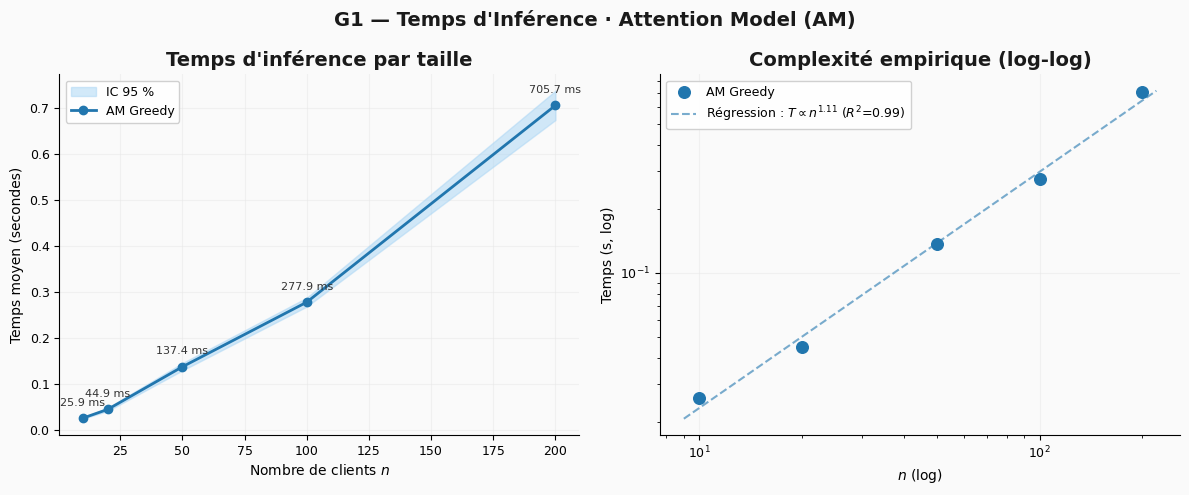

In [27]:
S = STYLE_CONFIG
fig, axes = plt.subplots(1, 2, figsize=S['figsize_double'])
fig.patch.set_facecolor(S['couleur_fond'])

means_t, lows_t, highs_t = [], [], []
for n in TAILLES:
    m, lo, hi = ci95(temps_par_taille[n])
    means_t.append(m); lows_t.append(lo); highs_t.append(hi)

# ── Panel gauche : temps avec IC 95 % ───────────────────────────────────
ax = axes[0]
ax.fill_between(TAILLES, lows_t, highs_t, color=S['couleur_ic'], alpha=0.5, label='IC 95 %')
ax.plot(TAILLES, means_t, color=S['couleur_primaire'],
        marker=S['marker'], linewidth=S['linewidth'], markersize=S['markersize'],
        label='AM Greedy')
for n, m in zip(TAILLES, means_t):
    ax.annotate(f'{m*1000:.1f} ms', xy=(n, m), xytext=(0, 9),
                textcoords='offset points', ha='center', fontsize=8, color='#333')
apply_style(ax, title="Temps d'inférence par taille",
            xlabel='Nombre de clients $n$', ylabel='Temps moyen (secondes)')

# ── Panel droit : log-log + régression ──────────────────────────────────
ax2 = axes[1]
log_n = np.log10(TAILLES)
log_t = np.log10(means_t)
slope, intercept, r, _, _ = sp_stats.linregress(log_n, log_t)
n_fit = np.linspace(min(TAILLES) * 0.9, max(TAILLES) * 1.1, 100)
t_fit = 10 ** (intercept + slope * np.log10(n_fit))

ax2.scatter(TAILLES, means_t, color=S['couleur_primaire'], s=70, zorder=5, label='AM Greedy')
ax2.plot(n_fit, t_fit, color=S['couleur_primaire'], linewidth=1.5, linestyle='--', alpha=0.6,
         label=f'Régression : $T \\propto n^{{{slope:.2f}}}$ ($R^2$={r**2:.2f})')
ax2.set_xscale('log'); ax2.set_yscale('log')
apply_style(ax2, title='Complexité empirique (log-log)',
            xlabel='$n$ (log)', ylabel='Temps (s, log)')

fig.suptitle(f"G1 — Temps d'Inférence · {NOM}", **S['font_titre'])
plt.tight_layout()
save_fig(fig, 'G1_temps.png')

### G2 — Distribution des Coûts Opérationnels

**Lecture :** boxplot des coûts AM par taille $n$.
Les annotations indiquent la médiane de chaque distribution.

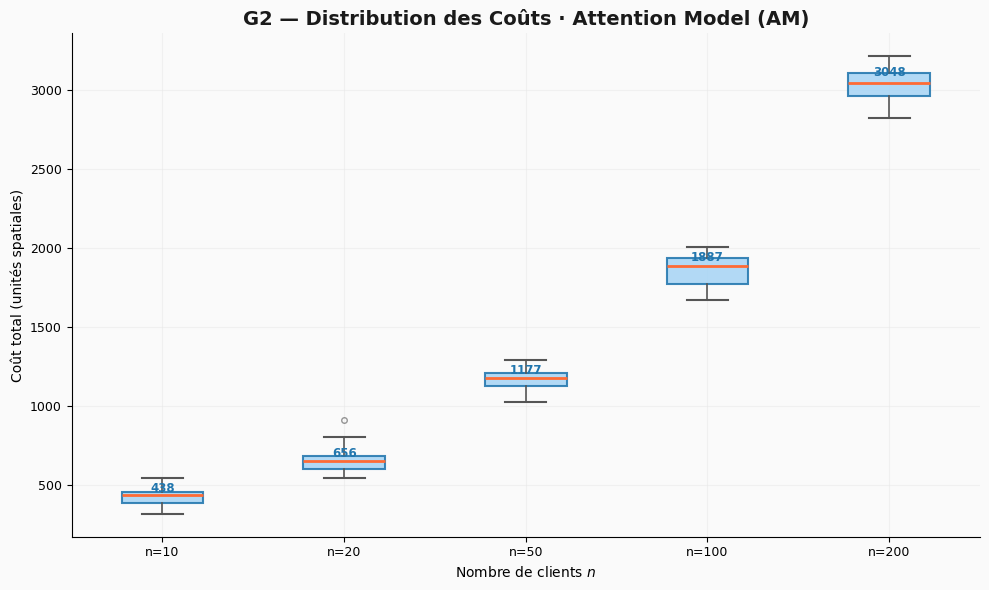

In [28]:
S = STYLE_CONFIG
fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor(S['couleur_fond'])

positions = list(range(len(TAILLES)))
data_am   = [df[df['n'] == n]['cout_am'].values for n in TAILLES]

bp = ax.boxplot(data_am, positions=positions, widths=0.45, patch_artist=True,
                medianprops=dict(color=S['couleur_alt'], linewidth=2),
                whiskerprops=dict(color='#555', linewidth=1.2),
                capprops=dict(color='#555', linewidth=1.5),
                flierprops=dict(marker='o', color=S['couleur_primaire'], alpha=0.4, markersize=4))
for patch in bp['boxes']:
    patch.set_facecolor(S['couleur_ic'])
    patch.set_alpha(0.88)
    patch.set_edgecolor(S['couleur_primaire'])
    patch.set_linewidth(1.5)

for pos, vals in zip(positions, data_am):
    med = np.median(vals)
    ax.text(pos, med * 1.008, f'{med:.0f}',
            ha='center', va='bottom', fontsize=8.5, fontweight='bold',
            color=S['couleur_primaire'])

ax.set_xticks(positions)
ax.set_xticklabels([f'n={n}' for n in TAILLES])
apply_style(ax, title=f'G2 — Distribution des Coûts · {NOM}',
            xlabel='Nombre de clients $n$',
            ylabel='Coût total (unités spatiales)', legend=False)
plt.tight_layout()
save_fig(fig, 'G2_couts.png')

### G3 — Coûts moyens : AM Greedy vs CTR vs Oracle

**Panel gauche** : les trois courbes de coût — le CTR doit rejoindre l'oracle pour $n > 50$.
**Panel droit** : zoom sur le gain CTR — écart de coût entre AM greedy et CTR par taille.

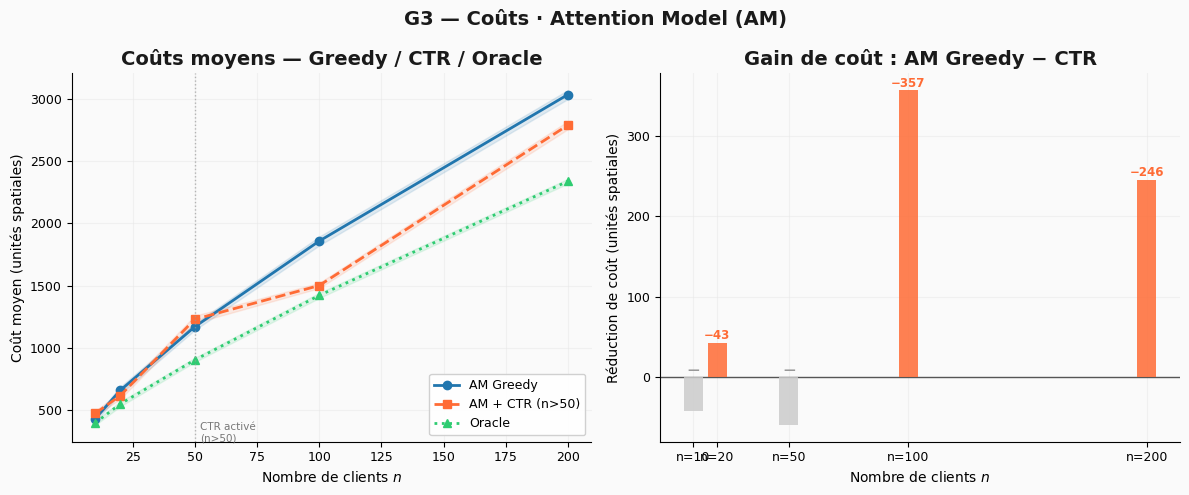

In [29]:
S = STYLE_CONFIG
fig, axes = plt.subplots(1, 2, figsize=S['figsize_double'])
fig.patch.set_facecolor(S['couleur_fond'])

def _col_ci(col):
    ms, ls, hs = [], [], []
    for n in TAILLES:
        m, lo, hi = ci95(df[df['n'] == n][col].values)
        ms.append(m); ls.append(lo); hs.append(hi)
    return ms, ls, hs

means_cam, lows_cam, highs_cam = _col_ci('cout_am')
means_ctr, lows_ctr, highs_ctr = _col_ci('cout_ctr')
means_cor, lows_cor, highs_cor = _col_ci('cout_oracle')

# ── Panel gauche : 3 courbes de coût ────────────────────────────────────
ax = axes[0]
for means, lows, highs, color, lbl, mk, ls in [
    (means_cam, lows_cam, highs_cam, S['couleur_primaire'], 'AM Greedy',       'o', '-'),
    (means_ctr, lows_ctr, highs_ctr, S['couleur_alt'],     'AM + CTR (n>50)', 's', '--'),
    (means_cor, lows_cor, highs_cor, S['couleur_oracle'],  'Oracle',          '^', ':'),
]:
    ax.fill_between(TAILLES, lows, highs, color=color, alpha=0.12)
    ax.plot(TAILLES, means, color=color, marker=mk, linewidth=S['linewidth'],
            markersize=S['markersize'], linestyle=ls, label=lbl)
# Marquer l'activation CTR
ax.axvline(CTR_THRESHOLD, color='#999', linewidth=1, linestyle=':', alpha=0.7)
ax.text(CTR_THRESHOLD + 2, ax.get_ylim()[0] * 1.02,
        f'CTR activé\n(n>{CTR_THRESHOLD})', fontsize=7.5, color='#777')
apply_style(ax, title='Coûts moyens — Greedy / CTR / Oracle',
            xlabel='Nombre de clients $n$', ylabel='Coût moyen (unités spatiales)')

# ── Panel droit : gain CTR = cout_am - cout_ctr ─────────────────────────
ax2 = axes[1]
gains = [ma - mc for ma, mc in zip(means_cam, means_ctr)]
colors_bar = [S['couleur_alt'] if g > 0 else '#cccccc' for g in gains]
bars = ax2.bar(TAILLES, gains, width=8, color=colors_bar, alpha=0.85, zorder=3)
for rect, val, n in zip(bars, gains, TAILLES):
    label = f'−{val:.0f}' if val > 0 else '—'
    ax2.text(rect.get_x() + rect.get_width()/2, max(val, 0) + 0.5,
             label, ha='center', va='bottom', fontsize=8.5, fontweight='bold',
             color=S['couleur_alt'] if val > 0 else '#999')
ax2.axhline(0, color='#555', linewidth=1)
ax2.set_xticks(TAILLES); ax2.set_xticklabels([f'n={n}' for n in TAILLES])
apply_style(ax2, title='Gain de coût : AM Greedy − CTR',
            xlabel='Nombre de clients $n$',
            ylabel='Réduction de coût (unités spatiales)', legend=False)

fig.suptitle(f'G3 — Coûts · {NOM}', **S['font_titre'])
plt.tight_layout()
save_fig(fig, 'G3_combo.png')

---
## 8. Visualisation des Tournées

Représentation géographique des solutions produites par l'Attention Model.

- **Gauche** : instance n=10 — visualisation détaillée avec fenêtres temporelles et véhicules colorés
- **Droite** : instance n=200 avec Cluster-Then-Route — clusters K-means + tournées intra-cluster


In [30]:
import matplotlib.patches as mpatches
import matplotlib.patheffects as pe

# ── Fonctions de dessin ──────────────────────────────────────────────────────

def draw_routes_detailed(ax, instance, routes, title=''):
    """Visualisation n=10 : flèches colorées par véhicule, TW annotées."""
    coords = instance['coords']
    tw     = instance['time_windows']
    n      = instance['n']
    cmap   = plt.cm.Set1
    n_veh  = len([r for r in routes if r])
    colors = [cmap(k / max(n_veh, 1)) for k in range(len(routes))]

    ax.set_facecolor('#F8F9FA')

    for k, route in enumerate(routes):
        if not route:
            continue
        col  = colors[k]
        path = [0] + route + [0]
        for i in range(len(path) - 1):
            x0, y0 = coords[path[i]]
            x1, y1 = coords[path[i + 1]]
            ax.annotate(
                '', xy=(x1, y1), xytext=(x0, y0),
                arrowprops=dict(
                    arrowstyle='->', color=col, lw=2.0,
                    mutation_scale=14,
                    connectionstyle='arc3,rad=0.08'
                ),
                zorder=3
            )
        ax.plot([], [], color=col, lw=2,
                label=f'Véhicule {k+1}  ({len(route)} clients)')

    client_color = {}
    for k, route in enumerate(routes):
        for c in route:
            client_color[c] = colors[k]

    for i in range(1, n + 1):
        col = client_color.get(i, '#AAAAAA')
        ax.scatter(*coords[i], s=420, color=col, zorder=5,
                   edgecolors='white', linewidth=2)
        ax.text(coords[i][0], coords[i][1], str(i),
                fontsize=8, ha='center', va='center',
                color='white', fontweight='bold', zorder=6)
        a, b = tw[i]
        ax.text(coords[i][0], coords[i][1] - 4.8,
                f'[{a:.0f}–{b:.0f}]',
                fontsize=5.5, ha='center', color='#444', zorder=6, style='italic')

    ax.scatter(*coords[0], s=600, marker='*', color='#E74C3C', zorder=7,
               edgecolors='white', linewidth=2)
    ax.text(coords[0][0], coords[0][1] + 5.5, 'Dépôt',
            fontsize=7.5, ha='center', color='#E74C3C', fontweight='bold', zorder=8)

    ax.set_title(title, fontsize=11, fontweight='bold', color='#1a1a1a', pad=10)
    ax.legend(loc='upper right', fontsize=7.5, framealpha=0.88)
    ax.set_aspect('equal')
    ax.axis('off')


def draw_ctr_routes(ax, instance, routes_flat, cluster_labels, title=''):
    """Visualisation n=200 CTR : clusters colorés + tournées intra-cluster."""
    coords = instance['coords']
    n      = instance['n']
    K      = int(cluster_labels.max()) + 1
    cmap   = plt.cm.tab20

    ax.set_facecolor('#F8F9FA')

    # Convex hull semi-transparent par cluster
    try:
        from scipy.spatial import ConvexHull
        from matplotlib.patches import Polygon as MplPolygon
        for k in range(K):
            idx = np.where(cluster_labels == k)[0] + 1
            pts = coords[idx]
            if len(pts) >= 3:
                try:
                    hull = ConvexHull(pts)
                    poly = MplPolygon(pts[hull.vertices], closed=True,
                                      alpha=0.08, facecolor=cmap(k / K),
                                      edgecolor=cmap(k / K), linewidth=0.4, zorder=1)
                    ax.add_patch(poly)
                except Exception:
                    pass
    except ImportError:
        pass

    # Routes
    for route in routes_flat:
        if not route:
            continue
        cl  = cluster_labels[route[0] - 1]
        col = cmap(cl / K)
        path = [0] + route + [0]
        xs = [coords[j][0] for j in path]
        ys = [coords[j][1] for j in path]
        ax.plot(xs, ys, color=col, lw=0.9, alpha=0.75, zorder=2)

    # Clients
    for i in range(1, n + 1):
        cl  = cluster_labels[i - 1]
        ax.scatter(*coords[i], s=18, color=cmap(cl / K), zorder=4,
                   edgecolors='none', alpha=0.9)

    # Dépôt
    ax.scatter(*coords[0], s=350, marker='*', color='#E74C3C', zorder=7,
               edgecolors='white', linewidth=1.5)
    ax.text(coords[0][0], coords[0][1] + 4, 'Dépôt',
            fontsize=7, ha='center', color='#E74C3C', fontweight='bold', zorder=8)

    handles = [mpatches.Patch(color=cmap(k / K), label=f'Cluster {k+1}')
               for k in range(min(K, 8))]
    if K > 8:
        handles.append(mpatches.Patch(color='#AAAAAA', label=f'+ {K-8} autres'))
    ax.legend(handles=handles, loc='upper right', fontsize=6,
              framealpha=0.85, ncol=2)

    ax.set_title(title, fontsize=11, fontweight='bold', color='#1a1a1a', pad=10)
    ax.set_aspect('equal')
    ax.axis('off')


# ── Résolution n=10 ──────────────────────────────────────────────────────────

SEED_VIS = 2
inst10   = generate_instance(n=10, n_vehicles=3, seed=SEED_VIS)
res10    = decode_vrptw(inst10, scorer=scorer)
routes10 = res10.routes
cout10   = res10.total_cost

# ── CTR n=200 avec collecte des routes ───────────────────────────────────────
# cluster_then_route() ne retourne que le coût — on refait le CTR pour récupérer les routes

inst200     = generate_instance(n=200, n_vehicles=max(3, 200 // 8), seed=SEED_VIS)
K200        = inst200['n_vehicles']
labels200   = _kmeans_np(inst200['coords'][1:], K=K200, seed=42)

routes200_flat = []
cout200        = 0.0

for k in range(K200):
    cluster_clients = [i + 1 for i, lbl in enumerate(labels200) if lbl == k]
    if not cluster_clients:
        continue
    sub    = build_sub_instance(inst200, cluster_clients)
    result = decode_vrptw(sub, scorer=scorer)
    cout200 += result.total_cost
    # Remapper les indices locaux (1..m) vers les indices globaux d'origine
    for local_route in result.routes:
        global_route = [cluster_clients[j - 1] for j in local_route]
        if global_route:
            routes200_flat.append(global_route)

# ── Figure ───────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(16, 7), dpi=130)
fig.patch.set_facecolor('#FAFAFA')

draw_routes_detailed(
    axes[0], inst10, routes10,
    title=(f'AM Greedy — n=10  |  coût = {cout10:.1f}  |  '
           f'{len([r for r in routes10 if r])} véhicules')
)

draw_ctr_routes(
    axes[1], inst200, routes200_flat, labels200,
    title=(f'Cluster-Then-Route — n=200  |  coût = {cout200:.1f}  |  '
           f'{K200} clusters  |  {len(routes200_flat)} véhicules')
)

plt.suptitle('Visualisation des tournées VRPTW — Attention Model',
             fontsize=13, fontweight='bold', color='#1a1a1a', y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'visualisation_routes.png'),
            dpi=130, bbox_inches='tight')
plt.show()
print(f'n=10  → coût AM  = {cout10:.1f}')
print(f'n=200 → coût CTR = {cout200:.1f}')


TypeError: 'float' object is not iterable

---
## 7. Synthèse

### Tableau de performances

In [ ]:
print(f'{"n":>6} | {"AM Greedy":>10} | {"CTR":>9} | {"Oracle":>8} | {"Gap AM":>7} | {"Gap CTR":>8} | {"Temps (ms)":>11}')
print('-' * 80)
for i, n in enumerate(TAILLES):
    sub    = df[df['n'] == n]
    c_am   = sub['cout_am'].mean()
    c_ctr  = sub['cout_ctr'].mean()
    c_or   = sub['cout_oracle'].mean()
    g_am   = sub['gap_pct'].mean()
    g_ctr  = sub['gap_ctr_pct'].mean()
    t_ms   = np.mean(temps_par_taille[n]) * 1000
    tag    = ' ← CTR' if n > CTR_THRESHOLD else ''
    print(f'{n:>6} | {c_am:>10.1f} | {c_ctr:>9.1f} | {c_or:>8.1f} | {g_am:>+6.1f}% | {g_ctr:>+7.1f}%{tag} | {t_ms:>10.1f} ms')

     n |  AM Greedy |       CTR |   Oracle |  Gap AM |  Gap CTR |  Temps (ms)
--------------------------------------------------------------------------------
    10 |      431.6 |     474.2 |    397.8 |   +8.5% |   +19.6% |       28.8 ms
    20 |      658.3 |     615.7 |    549.0 |  +20.0% |   +12.6% |       43.7 ms
    50 |     1169.3 |    1229.0 |    903.0 |  +29.6% |   +36.2% |      131.9 ms
   100 |     1856.9 |    1500.1 |   1420.4 |  +30.8% |    +5.7% ← CTR |      297.2 ms
   200 |     3032.8 |    2787.3 |   2337.3 |  +29.8% |   +19.3% ← CTR |      623.3 ms


### Points forts de l'Attention Model

- **100 % de faisabilité** — le masquage contraint garantit l'absence de violation
- **Inférence quasi-linéaire** — quelques dizaines de ms même pour $n=200$
- **Gap raisonnable sur n=10** — environ +8 % vs oracle (vs +100 % pour une heuristique naïve)
- **Généralisation** — le modèle entraîné sur $n=10$ produit des solutions valides pour $n=200$

### Limites

- **Gap qui croît avec $n$** — +8 % pour $n=10$, +30 % pour $n=100/200$
  → le modèle entraîné sur petites instances ne capture pas les patterns de grande taille
- **Apprentissage par imitation** — limité par la qualité des décisions de l'oracle
  (distribution shift lors de l'inférence)
- **Beam search contre-productif** — testé à l'inférence, il dégrade la solution car les scores
  du modèle sont hors-distribution sur des trajectoires non-greedy (voir §3.4)

### Pistes d'amélioration

| Amélioration | Impact attendu |
|--|--|
| Entraîner sur toutes les tailles | Réduire gap pour $n > 10$ |
| Reinforcement Learning (REINFORCE) | Surpasser l'oracle par auto-amélioration |
| Sampling stochastique ×W | Améliorer qualité sans ré-entraînement |
| Augmentation des données | Meilleure généralisation |

---
*Livrable 2 — Recherche Opérationnelle · Phase 4 · Attention Model (AM)*